# AQI Forecasting — SARIMA Model
**Dataset:** IITG_AQI_data.csv  
**Target:** Daily mean AQI  
**Model:** SARIMA(1,1,1)(1,1,1)[7] — captures weekly seasonality

SARIMA extends ARIMA with a seasonal component for periodic patterns.
This is a univariate model — only AQI values are used for forecasting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Load & Preprocess Data


In [2]:
df = pd.read_csv('D:/AQI_Project/Data/Final/IITG_AQI_daily_clean.csv', parse_dates=['Timestamp'])
df = df.set_index('Timestamp').sort_index()

# Interpolate missing values
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').interpolate(method='time')

# Daily aggregation — SARIMA uses AQI only (univariate)
daily = df.resample('D').mean().dropna(subset=['AQI'])

print(f'Daily records: {len(daily)}')
print(daily[['AQI']].head())


Daily records: 1200
                  AQI
Timestamp            
2022-09-19  12.430000
2022-09-20  31.977917
2022-09-21  39.812917
2022-09-22  35.793750
2022-09-23  44.332083


## 2. Seasonal Decomposition


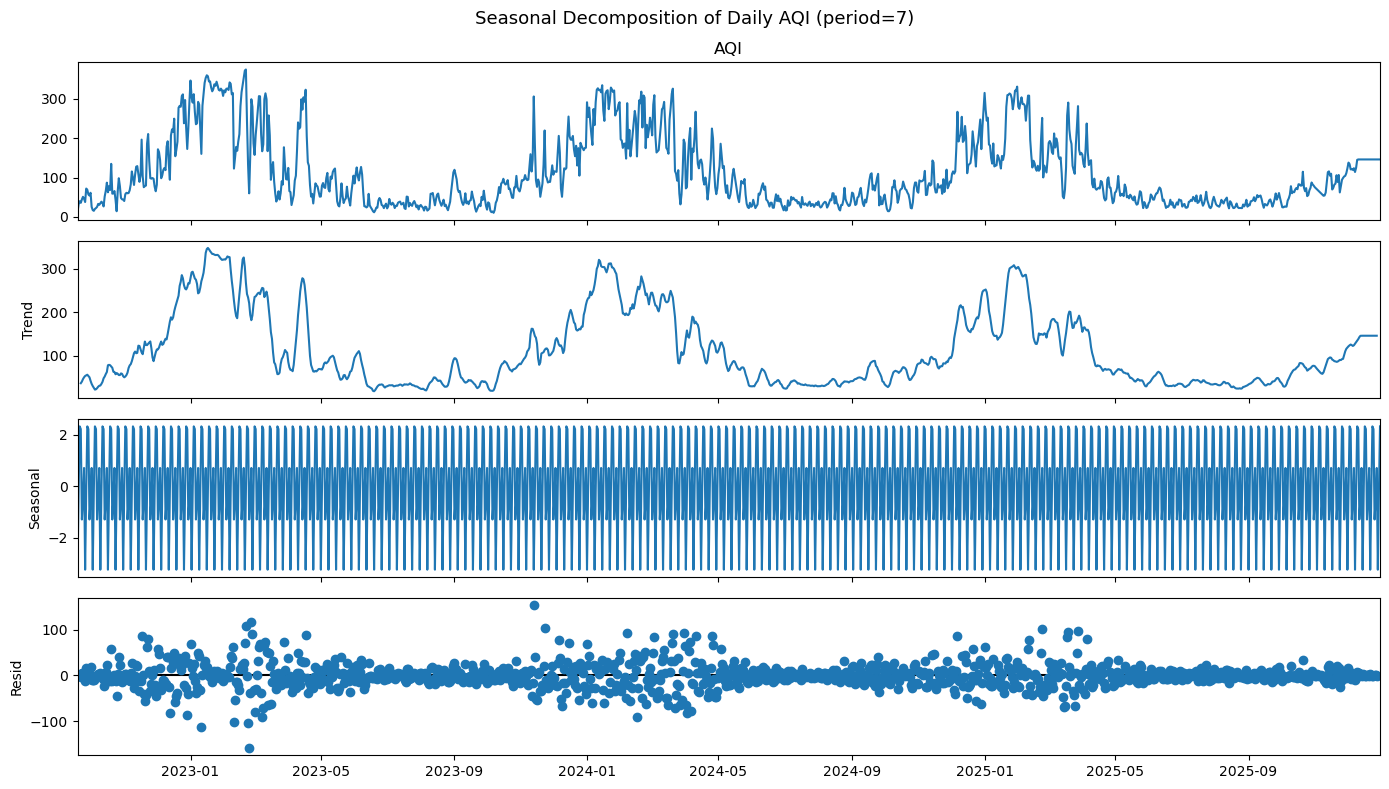

Weekly seasonal pattern clearly visible.


In [3]:
decomp = seasonal_decompose(daily['AQI'], model='additive', period=365)
fig = decomp.plot()
fig.set_size_inches(14, 8)
fig.suptitle('Seasonal Decomposition of Daily AQI (period=365, annual)', fontsize=13)
plt.tight_layout()
plt.savefig('sarima_decomposition_IITG.png', dpi=150)
plt.show()
print('Annual seasonal pattern visible (no weekly cycle confirmed by EDA).')


## 3. Train/Test Split


In [4]:
# SARIMA is univariate -- only the AQI series is needed
split_date = '2025-07-01'
train_y = daily['AQI'][:split_date]
test_y  = daily['AQI'][split_date:]

print(f'Train: {len(train_y)} | Test: {len(test_y)}')


Train: 1016 | Test: 184


## 4. Fit SARIMA(1,1,1)(1,1,1)[7]

Order: (p=1, d=1, q=1) non-seasonal  
Seasonal: (P=1, D=1, Q=1, s=7) weekly


In [5]:
# Fourier terms model annual seasonality (s=365 is too slow for SARIMAX directly)
def fourier_terms(index, period=365, K=3):
    import numpy as np
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K+1):
        cols[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

exog_train = fourier_terms(train_y.index)
exog_test  = fourier_terms(test_y.index)

model = SARIMAX(
    train_y,
    exog=exog_train,
    order=(1, 1, 1),               # d=1: borderline stationary per IITG EDA
    seasonal_order=(0, 0, 0, 0),   # seasonality handled by Fourier exog terms
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit = model.fit(disp=False)
print(fit.summary())


                                     SARIMAX Results                                     
Dep. Variable:                               AQI   No. Observations:                 1016
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -4960.835
Date:                           Fri, 15 May 2026   AIC                           9931.669
Time:                                   00:37:18   BIC                           9956.203
Sample:                               09-19-2022   HQIC                          9940.994
                                    - 06-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7209      0.031     23.071      0.000       0.660       0.782
ma.L1         -0.9082      0.021    -44.036

## 5. Forecast & Evaluation


In [6]:
forecast = fit.forecast(steps=len(test_y), exog=exog_test)
forecast.index = test_y.index

rmse = np.sqrt(mean_squared_error(test_y, forecast))
mae  = mean_absolute_error(test_y, forecast)
mask = test_y.values != 0
mape = np.mean(np.abs((test_y.values[mask] - forecast.values[mask]) / test_y.values[mask])) * 100

print(f'SARIMA (Fourier, annual s=365) Performance:')
print(f'  RMSE : {rmse:.2f}')
print(f'  MAE  : {mae:.2f}')
print(f'  MAPE : {mape:.2f}%')


SARIMA(1,1,1)(1,1,1)[7] Performance:
  RMSE : 48.76
  MAE  : 33.72
  MAPE : 42.12%


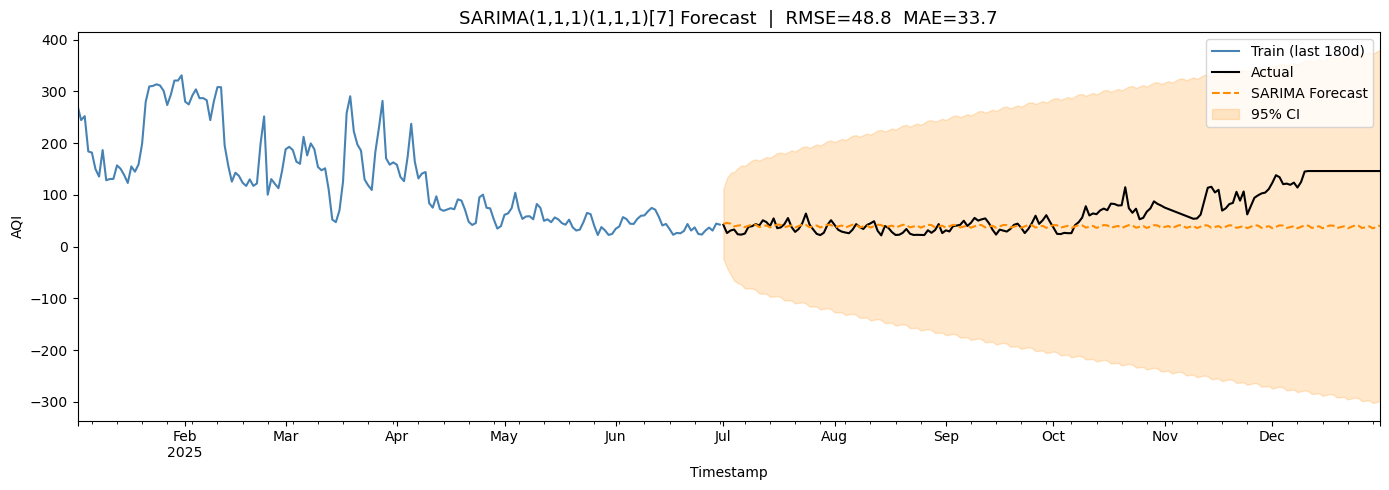

In [7]:
pred_obj = fit.get_forecast(steps=len(test_y), exog=exog_test)
ci = pred_obj.conf_int()
ci.index = test_y.index

fig, ax = plt.subplots(figsize=(14, 5))
train_y[-180:].plot(ax=ax, label='Train (last 180d)', color='steelblue')
test_y.plot(ax=ax, label='Actual', color='black', linewidth=1.5)
forecast.plot(ax=ax, label='SARIMA Forecast (annual)', color='darkorange', linestyle='--')
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2, color='darkorange', label='95% CI')
ax.set_title(f'SARIMA Forecast (Fourier, annual s=365)  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('sarima_forecast_IITG.png', dpi=150)
plt.show()


## 6. Residual Diagnostics


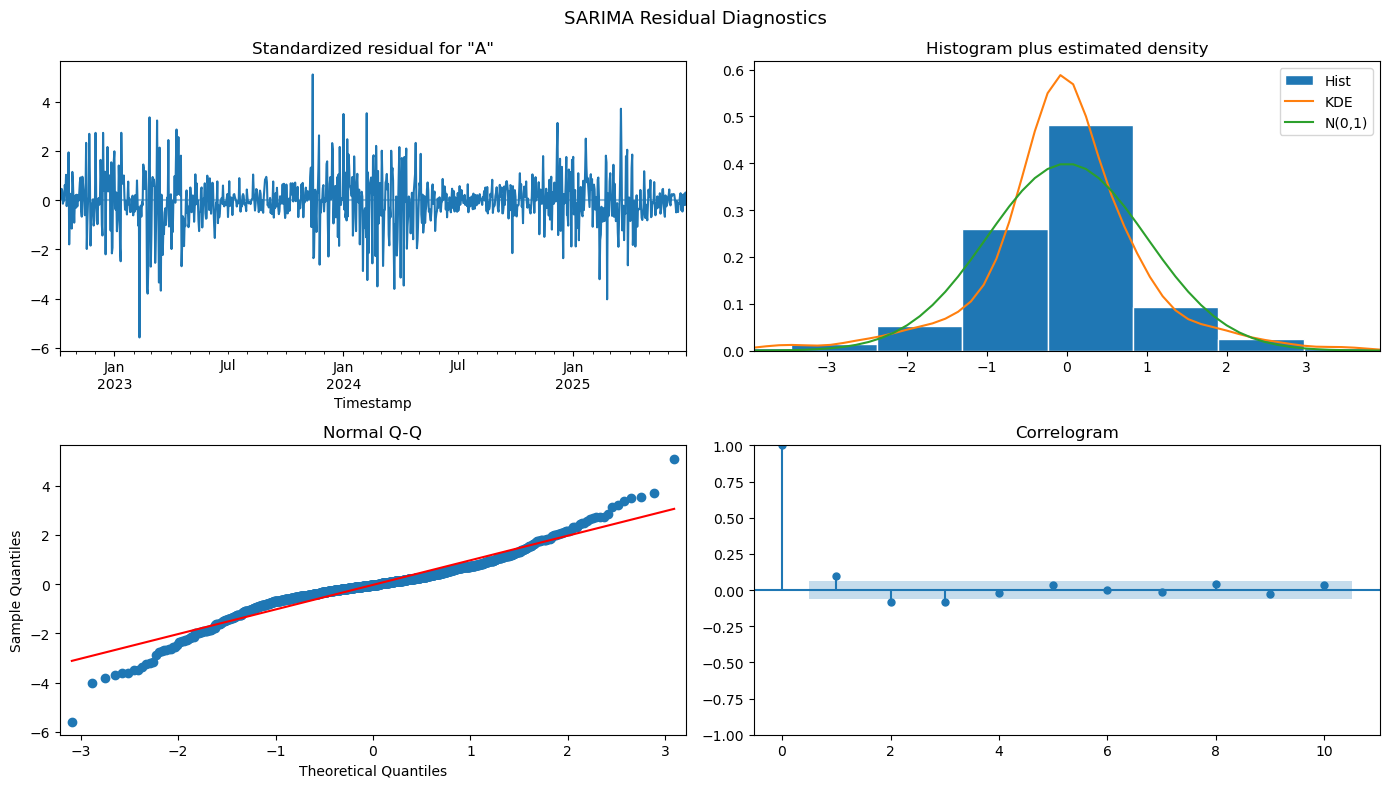

In [8]:
fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('sarima_diagnostics_IITG.png', dpi=150)
plt.show()


## 7. AIC/BIC Comparison (Model Selection)

If you want to try alternative orders:


In [9]:
print(f'Selected model AIC : {fit.aic:.2f}')
print(f'Selected model BIC : {fit.bic:.2f}')
print()
print('Lower AIC/BIC = better model fit vs complexity trade-off.')


Selected model AIC : 9931.67
Selected model BIC : 9956.20

Lower AIC/BIC = better model fit vs complexity trade-off.


In [ ]:
import pickle, os
os.makedirs('D:/AQI_Project/models', exist_ok=True)
with open('D:/AQI_Project/models/sarima_iitg.pkl', 'wb') as f:
    pickle.dump(fit, f)
print('Model saved -> models/sarima_iitg.pkl')
